Saving Salary_dataset.csv to Salary_dataset.csv

Dataset Preview:


,YearsExperience,Salary
0,1.2,39344.0
1,1.4,46206.0
2,1.6,37732.0
3,2.1,43526.0
4,2.3,39892.0



----- MODEL PERFORMANCE METRICS -----
Mean Absolute Error (MAE): 5161.3287
Mean Squared Error (MSE): 37784662.4662
Root Mean Squared Error (RMSE): 6146.9230
R-squared Score (R²): 0.9414 (94.14%)
Mean Absolute Percentage Error (MAPE): 0.0665 (6.65%)

----- REGRESSION EQUATION -----
Intercept (β0): 24985.5302
Slope (β1): 9339.0817

Mathematical Equation:
Salary = 24985.5302 + (9339.0817 × YearsExperience)


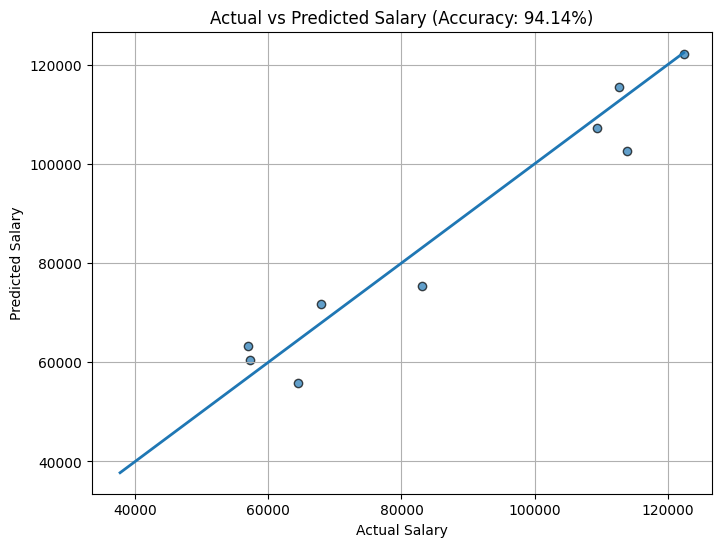

In [ ]:
# =======================
# LINEAR REGRESSION LAB
# SINGLE CELL CODE
# =======================

# Upload CSV at runtime
from google.colab import files
uploaded = files.upload()

# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

# Load dataset
file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)

# Data Cleaning
if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)

# Display dataset info
print("\nDataset Preview:")
display(df.head())

# Feature selection (Salary Dataset)
X = df[['YearsExperience']]
y = df['Salary']

# Train-Test Split (70% Train, 30% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Model Training
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Performance Metrics
mae = metrics.mean_absolute_error(y_test, y_pred)
mse = metrics.mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = metrics.r2_score(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test))

print("\n----- MODEL PERFORMANCE METRICS -----")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared Score (R²): {r2:.4f} ({r2*100:.2f}%)")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.4f} ({mape*100:.2f}%)")

# Regression Equation
print("\n----- REGRESSION EQUATION -----")
print(f"Intercept (β0): {model.intercept_:.4f}")
print(f"Slope (β1): {model.coef_[0]:.4f}")

equation = f"Salary = {model.intercept_:.4f} + ({model.coef_[0]:.4f} × YearsExperience)"
print(f"\nMathematical Equation:\n{equation}")

# Visualization: Actual vs Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, edgecolor='black', alpha=0.7)
plt.plot([y.min(), y.max()], [y.min(), y.max()], linewidth=2)
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title(f"Actual vs Predicted Salary (Accuracy: {r2*100:.2f}%)")
plt.grid(True)
plt.show()

========== LINEAR REGRESSION ==========



Saving Housing.csv to Housing (1).csv
Dataset Preview:
      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  

Model Performance:
MSE: 0.6078468389300876


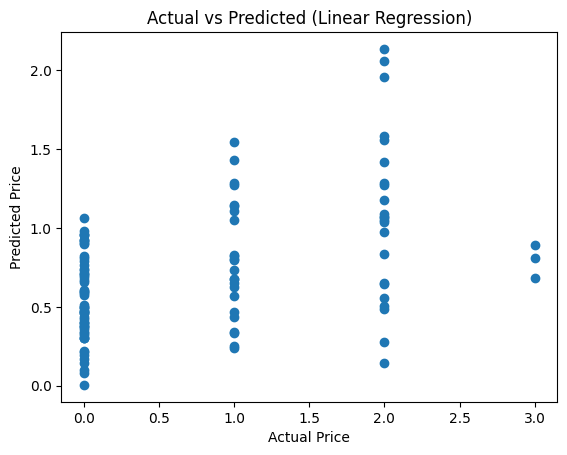

FileNotFoundError: [Errno 2] No such file or directory: 'heart.csv'

In [ ]:
# ===============================
# LINEAR + LOGISTIC REGRESSION
# ===============================

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# =====================================================
# PART 1 : LINEAR REGRESSION (House Price Dataset)
# =====================================================

print("========== LINEAR REGRESSION ==========\n")

# Upload house price dataset
from google.colab import files
uploaded = files.upload()
df1 = pd.read_csv(list(uploaded.keys())[0])

print("Dataset Preview:")
print(df1.head())

# Keep only numeric columns
df1 = df1.select_dtypes(include=np.number)

# Assume last column is target (price)
X = df1.iloc[:, :-1]
y = df1.iloc[:, -1]

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)

# Predict
y_pred = lin_model.predict(X_test)

# Evaluation
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nModel Performance:")
print("MSE:", mse)
print("R2 Score:", r2)

# Plot
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted (Linear Regression)")
plt.show()


# =====================================================
# PART 2 : LOGISTIC REGRESSION (Heart Disease Dataset)
# =====================================================
# ===============================
# LOGISTIC REGRESSION (Heart Disease Dataset)
# ===============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load dataset
df2 = pd.read_csv("heart.csv")   # make sure filename matches

print("Columns in Dataset:")
print(df2.columns)

# Features and Target
X = df2.drop("output", axis=1)   # Target column is 'output'
y = df2["output"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train model
model = LogisticRegression(max_iter=10000)
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Evaluation
print("\n===== Model Performance =====")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

===== Dataset Preview =====
      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  

===== Processed Dataset =====
      price  area  bedrooms  bathrooms  

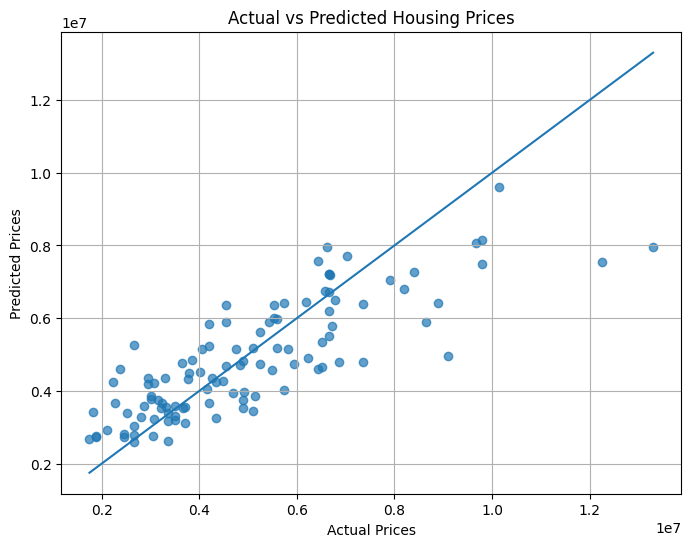

In [ ]:
# ===============================
# LINEAR REGRESSION (Housing Dataset)
# ===============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

# Load dataset
df = pd.read_csv("Housing.csv")

print("===== Dataset Preview =====")
print(df.head())

# Convert categorical columns
df = pd.get_dummies(df, drop_first=True)

print("\n===== Processed Dataset =====")
print(df.head())

# Features and target
X = df.drop("price", axis=1)
y = df["price"]

print("\n===== Features Used =====")
print(X.columns)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Model evaluation
mae = metrics.mean_absolute_error(y_test, y_pred)
mse = metrics.mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = metrics.r2_score(y_test, y_pred)

print("\n===== Model Performance =====")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared Score (R2): {r2:.4f} ({r2*100:.2f}%)")

# Regression equation details
print("\n===== Regression Equation Details =====")
print(f"Intercept (b0): {model.intercept_:.4f}")

coeff_df = pd.DataFrame(model.coef_, X.columns, columns=["Coefficient"])
print(coeff_df)

# Actual vs Predicted Plot
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y.min(), y.max()], [y.min(), y.max()])
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Housing Prices")
plt.grid(True)
plt.show()

In [ ]:
# ===============================
# LOGISTIC REGRESSION (Heart Dataset - UCI Version)
# ===============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score

# Load dataset
df = pd.read_csv("heart.csv")   # use exact file name

print("===== Dataset Preview =====")
print(df.head())

print("\nColumns:", df.columns)

# Target column is 'num'
X = df.drop("num", axis=1)
y = df["num"]

# Convert to binary (important for UCI dataset)
y = y.apply(lambda x: 1 if x > 0 else 0)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train model
model = LogisticRegression(max_iter=10000)
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Performance metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\n===== Model Performance =====")
print(f"Accuracy: {acc:.4f} ({acc*100:.2f}%)")
print(f"Precision: {prec:.4f} ({prec*100:.2f}%)")
print(f"Recall: {rec:.4f} ({rec*100:.2f}%)")
print(f"F1 Score: {f1:.4f} ({f1*100:.2f}%)")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print("\n===== Confusion Matrix Values =====")
print(f"TP: {tp}, TN: {tn}, FP: {fp}, FN: {fn}")

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'heart.csv'

In [ ]:
from google.colab import files
uploaded = files.upload()

In [ ]:
import os
print(os.listdir())

['.config', 'heart_disease_uci.csv', 'Housing.csv', '.ipynb_checkpoints', 'Housing (1).csv', 'sample_data']


Files in Directory:
['.config', 'heart_disease_uci.csv', 'Housing.csv', '.ipynb_checkpoints', 'Housing (1).csv', 'sample_data']


========== LINEAR REGRESSION ==========

===== Dataset Preview =====
      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3

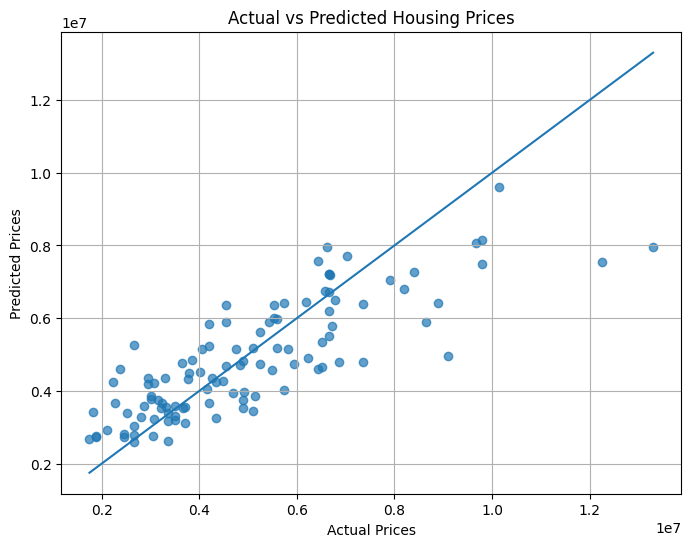



========== LOGISTIC REGRESSION ==========

===== Hyperparameter Tuning =====
C = 0.01 --> Accuracy = 0.8315
C = 0.1 --> Accuracy = 0.8315
C = 1 --> Accuracy = 0.8424
C = 10 --> Accuracy = 0.8370
C = 100 --> Accuracy = 0.8315

Best C Value: 1
Best Accuracy: 0.8424

===== Final Model Performance =====
Accuracy: 0.8424 (84.24%)
Precision: 0.8774 (87.74%)
Recall: 0.8532 (85.32%)
F1 Score: 0.8651 (86.51%)

===== Confusion Matrix Values =====
TP: 93, TN: 62, FP: 13, FN: 16


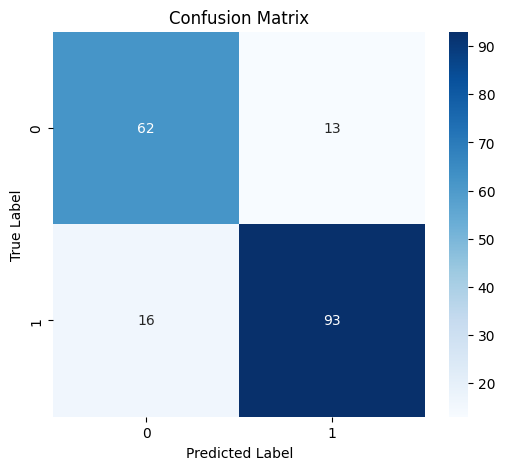

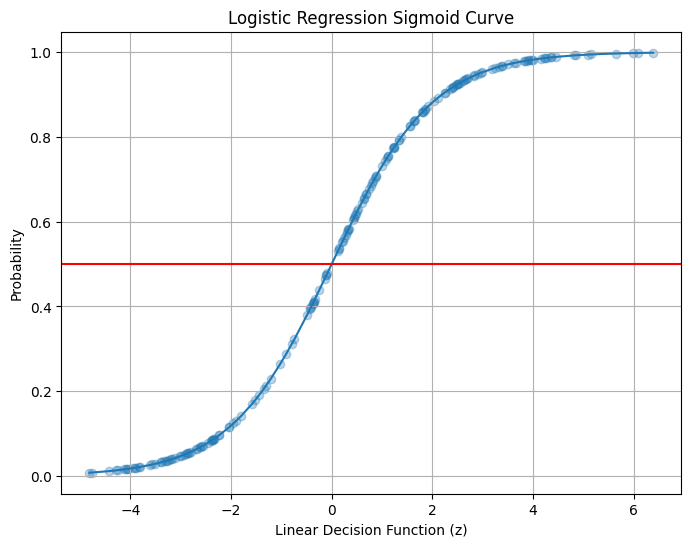

In [ ]:
# =====================================================
# FINAL EXPERIMENT
# LINEAR + LOGISTIC REGRESSION
# =====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn import metrics
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score

print("Files in Directory:")
print(os.listdir())

# =====================================================
# PART 1 : LINEAR REGRESSION (Housing Dataset)
# =====================================================

print("\n\n========== LINEAR REGRESSION ==========")

# Load Housing Dataset
df1 = pd.read_csv("Housing.csv")

print("\n===== Dataset Preview =====")
print(df1.head())

# Convert categorical variables
df1 = pd.get_dummies(df1, drop_first=True)

print("\n===== Processed Dataset =====")
print(df1.head())

# Features and Target
X1 = df1.drop("price", axis=1)
y1 = df1["price"]

print("\n===== Features Used =====")
print(X1.columns)

# Train-Test Split
X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size=0.2, random_state=42
)

# Train Model
lin_model = LinearRegression()
lin_model.fit(X1_train, y1_train)

# Prediction
y1_pred = lin_model.predict(X1_test)

# Evaluation
mae = metrics.mean_absolute_error(y1_test, y1_pred)
mse = metrics.mean_squared_error(y1_test, y1_pred)
rmse = np.sqrt(mse)
r2 = metrics.r2_score(y1_test, y1_pred)

print("\n===== Model Performance =====")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared Score (R2): {r2:.4f} ({r2*100:.2f}%)")

print("\n===== Regression Equation Details =====")
print(f"Intercept (b0): {lin_model.intercept_:.4f}")

coeff_df = pd.DataFrame(lin_model.coef_, X1.columns, columns=["Coefficient"])
print(coeff_df)

# Plot
plt.figure(figsize=(8,6))
plt.scatter(y1_test, y1_pred, alpha=0.7)
plt.plot([y1.min(), y1.max()], [y1.min(), y1.max()])
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Housing Prices")
plt.grid(True)
plt.show()


# =====================================================
# LOGISTIC REGRESSION WITH HYPERPARAMETER TUNING
# =====================================================

print("\n\n========== LOGISTIC REGRESSION ==========")

df2 = pd.read_csv("heart_disease_uci.csv")

# Convert categorical columns
df2 = pd.get_dummies(df2, drop_first=True)

# Handle missing values
df2 = df2.fillna(df2.median())

# Features and target
X2 = df2.drop("num", axis=1)
y2 = df2["num"]

# Convert to binary
y2 = y2.apply(lambda x: 1 if x > 0 else 0)

# Train-Test Split
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)

# Feature Scaling
scaler = StandardScaler()
X2_train = scaler.fit_transform(X2_train)
X2_test = scaler.transform(X2_test)

# -----------------------------------------------------
# Hyperparameter Tuning (C values)
# -----------------------------------------------------

print("\n===== Hyperparameter Tuning =====")

C_values = [0.01, 0.1, 1, 10, 100]
best_acc = 0
best_C = None

for c in C_values:
    model = LogisticRegression(C=c, max_iter=10000)
    model.fit(X2_train, y2_train)
    y_pred_temp = model.predict(X2_test)
    acc_temp = accuracy_score(y2_test, y_pred_temp)

    print(f"C = {c} --> Accuracy = {acc_temp:.4f}")

    if acc_temp > best_acc:
        best_acc = acc_temp
        best_C = c

print(f"\nBest C Value: {best_C}")
print(f"Best Accuracy: {best_acc:.4f}")

# -----------------------------------------------------
# Train Final Model with Best C
# -----------------------------------------------------

log_model = LogisticRegression(C=best_C, max_iter=10000)
log_model.fit(X2_train, y2_train)

y2_pred = log_model.predict(X2_test)

# Metrics
acc = accuracy_score(y2_test, y2_pred)
prec = precision_score(y2_test, y2_pred)
rec = recall_score(y2_test, y2_pred)
f1 = f1_score(y2_test, y2_pred)

print("\n===== Final Model Performance =====")
print(f"Accuracy: {acc:.4f} ({acc*100:.2f}%)")
print(f"Precision: {prec:.4f} ({prec*100:.2f}%)")
print(f"Recall: {rec:.4f} ({rec*100:.2f}%)")
print(f"F1 Score: {f1:.4f} ({f1*100:.2f}%)")

# Confusion Matrix
cm = confusion_matrix(y2_test, y2_pred)
tn, fp, fn, tp = cm.ravel()

print("\n===== Confusion Matrix Values =====")
print(f"TP: {tp}, TN: {tn}, FP: {fp}, FN: {fn}")

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

# -----------------------------------------------------
# Sigmoid Curve
# -----------------------------------------------------

z = log_model.decision_function(X2_test)
prob = log_model.predict_proba(X2_test)[:,1]

idx = np.argsort(z)

plt.figure(figsize=(8,6))
plt.scatter(z, prob, alpha=0.3)
plt.plot(z[idx], prob[idx])
plt.axhline(0.5, color='red')
plt.xlabel("Linear Decision Function (z)")
plt.ylabel("Probability")
plt.title("Logistic Regression Sigmoid Curve")
plt.grid(True)
plt.show()